In [ ]:
from sklearn import tree
import random
import pandas as pd
import numpy as np   
from sklearn import utils
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
from sklearn.preprocessing import MinMaxScaler

rice = "../res/rice.csv"
credit = "../res/credit_approval.csv"
parkinsons = "../res/parkinsons.csv"

class Node:
    def __init__(self, attribute=None, label=None, majority=None,
                 threshold=None, is_cat=False):
        self.attribute = attribute
        self.label = label
        self.majority = majority
        self.threshold = threshold
        self.is_cat = is_cat
        self.children = {}

def stratified_k_fold(df, k=10, y="label"):
    folds = [[] for _ in range(k)]

    classes = df[y].unique()
    class_subsets = {}

    for c in classes:
        subset = df[df[y] == c].sample(frac=1).reset_index(drop=True)
        class_subsets[c] = subset

    for c in classes:
        subset = class_subsets[c]
        for i in range(len(subset)):
            folds[i % k].append(subset.iloc[i])

    folds = [pd.DataFrame(fold).reset_index(drop=True) for fold in folds]

    return folds

def preprocess_dataset(df, target_col):
    df = df.copy()
    Y = df[target_col].values

    if df[target_col].dtype == 'object':
        df[target_col] = pd.factorize(df[target_col])[0]
        Y = df[target_col].values

    cat_cols = [c for c in df.columns if c != target_col and (df[c].dtype == 'object' or "_cat" in c)]
    num_cols = [c for c in df.columns if c != target_col and (df[c].dtype in ['int64', 'float64'])]

    for col in cat_cols:
        df[col] = pd.factorize(df[col])[0]

    if num_cols:
        scaler = MinMaxScaler()
        df[num_cols] = scaler.fit_transform(df[num_cols])
        for col in num_cols:
            df[col] = df[col].round(2) 

    return utils.shuffle(df)

def entropy(df, y):
    if len(df) == 0: return 0
    probs = df[y].value_counts(normalize=True)
    return -sum(p * math.log2(p) for p in probs if p > 0)

def information_gain(df, attribute, y):
    total_entropy = entropy(df, y)
    values = df[attribute].unique()
    weighted_entropy = 0
    for val in values:
        subset = df[df[attribute] == val]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset, y)
    return total_entropy - weighted_entropy

def majority_class(df, y):
    if df.empty: return None
    return df[y].mode()[0]


def decision_tree(df, attributes, y='label', depth=0, max_depth=None, min_samples_split=2):
    if max_depth is not None and depth >= max_depth:
        return Node(label=majority_class(df, y))
    
    if len(df) < min_samples_split:
        return Node(label=majority_class(df, y))
    
    if len(df[y].unique()) <= 1:
        return Node(label=df[y].iloc[0] if not df.empty else None)
    
    if not attributes:
        return Node(label=majority_class(df, y))
    
    gains = {attr: information_gain(df, attr, y) for attr in attributes}
    best_attribute = max(gains, key=gains.get)

    root = Node(attribute=best_attribute, majority=majority_class(df, y))
    remaining_attrs = [a for a in attributes if a != best_attribute]

    for value in df[best_attribute].unique():
        subset = df[df[best_attribute] == value]
        root.children[value] = decision_tree(subset, remaining_attrs, y, depth=depth + 1, max_depth=max_depth, min_samples_split=min_samples_split)

    return root


# accuracy 
def accuracy(predictions, correct_labels):
    # count the number of correct predictions and divide it by all instances
    correct = 0
    for i in range(len(correct_labels)):
        if predictions[i] == correct_labels[i]:
            correct += 1
    return correct / len(correct_labels)

def predict_instance(node, instance):
    if node.label is not None:
        return node.label
    attribute_value = instance[node.attribute]
    if attribute_value not in node.children:
        return node.majority
    return predict_instance(node.children[attribute_value], instance)


def predict(tree, df):
    return [predict_instance(tree, row) for _, row in df.iterrows()]


def confusion_matrix(preds, labels, positive_class):
    TP = FP = TN = FN = 0

    for i in range(len(labels)):
        if labels[i] == positive_class and preds[i] == positive_class:
            TP += 1
        elif labels[i] != positive_class and preds[i] == positive_class:
            FP += 1
        elif labels[i] != positive_class and preds[i] != positive_class:
            TN += 1
        else:
            FN += 1

    return TP, FP, TN, FN

def accuracy(TP, FP, TN, FN):
    return (TP + TN) / (TP + FP + TN + FN + 1e-12)

def precision(TP, FP):
    return TP / (TP + FP + 1e-12)

def recall(TP, FN):
    return TP / (TP + FN + 1e-12)

def f1(TP, FP, FN):
    p = precision(TP, FP)
    r = recall(TP, FN)
    return 2 * p * r / (p + r + 1e-12)

def accuracy(preds, actual):
    return np.sum(preds == actual) / len(actual)


def run_kfold(df, target_col, k=10, max_depth=None, min_samples_split=2):
    training_accs = []
    testing_accs = []
    
    df_clean = preprocess_dataset(df, target_col)
    attributes = [c for c in df_clean.columns if c != target_col]

    folds = stratified_k_fold(df_clean, k=10, y=target_col)

    training_accs = []
    testing_accs = []
    
    for i in range(k):
        test_df = folds[i]
        train_df = pd.concat([folds[j] for j in range(k) if j != i])
              
        tree_model = decision_tree(train_df, attributes, target_col, max_depth=max_depth, min_samples_split=min_samples_split)

        train_preds = predict(tree_model, train_df)
        test_preds = predict(tree_model, test_df)

        training_accs.append(accuracy(train_preds, train_df[target_col].values))
        testing_accs.append(accuracy(test_preds, test_df[target_col].values))
        
        print(f"Fold {i+1}/{k} complete. Test Acc: {testing_accs[-1]:.4f}")

    return training_accs, testing_accs

Fold 1/10 complete. Test Acc: 0.8976
Fold 2/10 complete. Test Acc: 0.8898
Fold 3/10 complete. Test Acc: 0.9029
Fold 4/10 complete. Test Acc: 0.8950
Fold 5/10 complete. Test Acc: 0.8740
Fold 6/10 complete. Test Acc: 0.9160
Fold 7/10 complete. Test Acc: 0.8924
Fold 8/10 complete. Test Acc: 0.9081
Fold 9/10 complete. Test Acc: 0.9108
Fold 10/10 complete. Test Acc: 0.9081

Training Mean Accuracy: 0.9744
Training Std Dev: 0.0015
Testing Mean Accuracy: 0.8995
Testing Std Dev: 0.0117


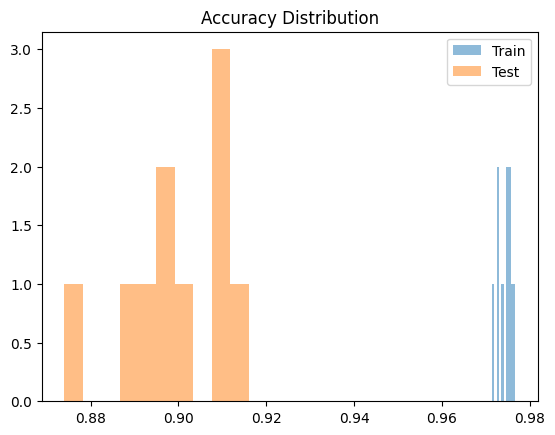

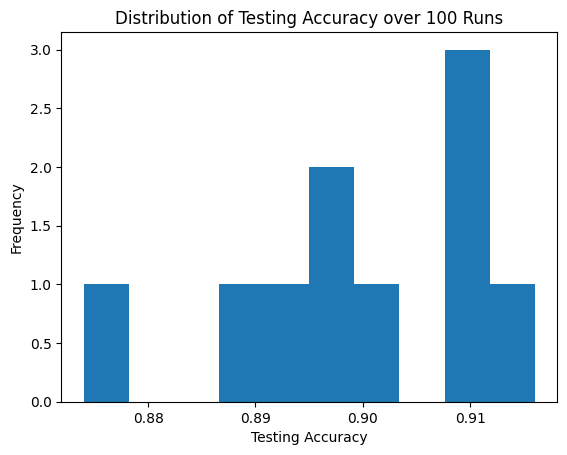

In [ ]:
rice_df = pd.read_csv(rice)
train_acc, test_acc = run_kfold(rice_df, "label", max_depth=5, min_samples_split=30)

print(f"\nTraining Mean Accuracy: {np.mean(train_acc):.4f}")
print(f"Training Std Dev: {np.std(train_acc):.4f}")

test_mean = np.mean(test_acc)
test_std = np.std(test_acc)

print(f"Testing Mean Accuracy: {test_mean:.4f}")
print(f"Testing Std Dev: {test_std:.4f}")

plt.hist(train_acc, bins=10, alpha=0.5, label='Train')
plt.hist(test_acc, bins=10, alpha=0.5, label='Test')
plt.legend()
plt.title("Accuracy Distribution")
plt.show()

plt.figure()
plt.hist(test_acc, bins=10)
plt.xlabel("Testing Accuracy")
plt.ylabel("Frequency")
plt.title("Distribution of Testing Accuracy over 100 Runs")
plt.show()

Fold 1/10 complete. Test Acc: 0.7727
Fold 2/10 complete. Test Acc: 0.7576
Fold 3/10 complete. Test Acc: 0.8182
Fold 4/10 complete. Test Acc: 0.8788
Fold 5/10 complete. Test Acc: 0.8485
Fold 6/10 complete. Test Acc: 0.8030
Fold 7/10 complete. Test Acc: 0.8000
Fold 8/10 complete. Test Acc: 0.8125
Fold 9/10 complete. Test Acc: 0.8438
Fold 10/10 complete. Test Acc: 0.8750

Training Mean Accuracy: 0.8739
Training Std Dev: 0.0045
Testing Mean Accuracy: 0.8210
Testing Std Dev: 0.0384


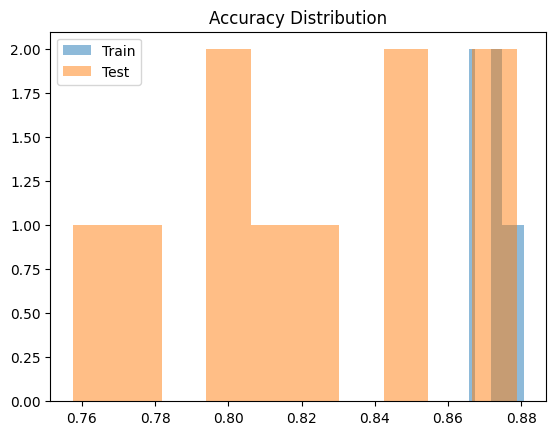

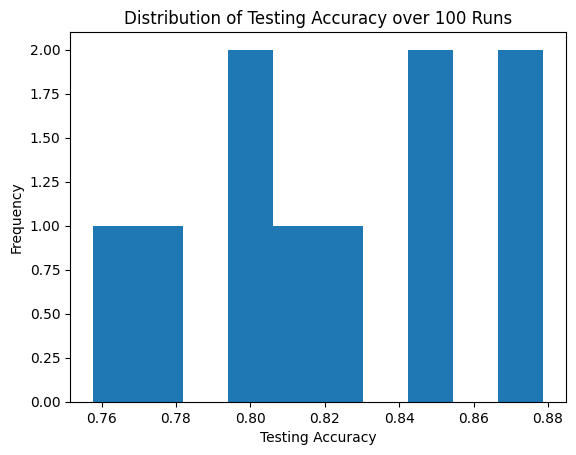

In [ ]:
credit_df = pd.read_csv(credit)
train_acc, test_acc = run_kfold(credit_df, "label", max_depth=5, min_samples_split=65)

print(f"\nTraining Mean Accuracy: {np.mean(train_acc):.4f}")
print(f"Training Std Dev: {np.std(train_acc):.4f}")

test_mean = np.mean(test_acc)
test_std = np.std(test_acc)

print(f"Testing Mean Accuracy: {test_mean:.4f}")
print(f"Testing Std Dev: {test_std:.4f}")

plt.hist(train_acc, bins=10, alpha=0.5, label='Train')
plt.hist(test_acc, bins=10, alpha=0.5, label='Test')
plt.legend()
plt.title("Accuracy Distribution")
plt.show()

plt.figure()
plt.hist(test_acc, bins=10)
plt.xlabel("Testing Accuracy")
plt.ylabel("Frequency")
plt.title("Distribution of Testing Accuracy over 100 Runs")
plt.show()

Fold 1/10 complete. Test Acc: 0.8000
Fold 2/10 complete. Test Acc: 0.6000
Fold 3/10 complete. Test Acc: 0.7000
Fold 4/10 complete. Test Acc: 0.6500
Fold 5/10 complete. Test Acc: 0.6500
Fold 6/10 complete. Test Acc: 0.7500
Fold 7/10 complete. Test Acc: 0.7000
Fold 8/10 complete. Test Acc: 0.7368
Fold 9/10 complete. Test Acc: 0.6111
Fold 10/10 complete. Test Acc: 0.6667

Training Mean Accuracy: 0.9750
Training Std Dev: 0.0185
Testing Mean Accuracy: 0.6865
Testing Std Dev: 0.0600


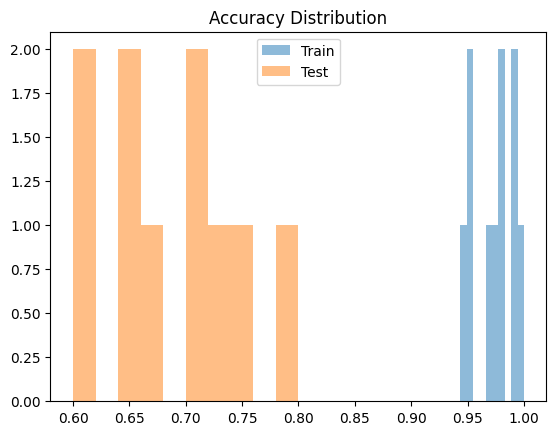

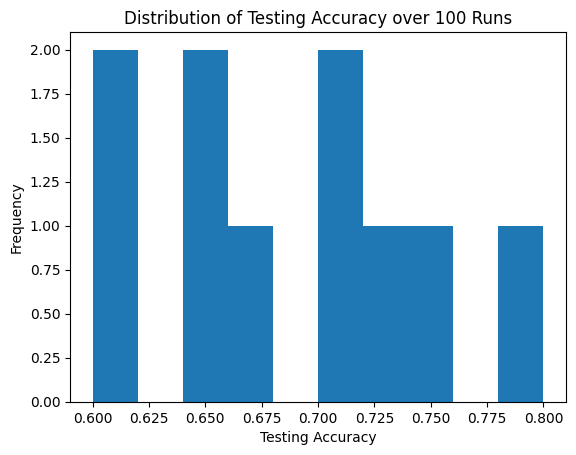

In [ ]:
parkinsons_df = pd.read_csv(parkinsons)
train_acc, test_acc = run_kfold(parkinsons_df, "Diagnosis", max_depth=6, min_samples_split=3)

print(f"\nTraining Mean Accuracy: {np.mean(train_acc):.4f}")
print(f"Training Std Dev: {np.std(train_acc):.4f}")

test_mean = np.mean(test_acc)
test_std = np.std(test_acc)

print(f"Testing Mean Accuracy: {test_mean:.4f}")
print(f"Testing Std Dev: {test_std:.4f}")

plt.hist(train_acc, bins=10, alpha=0.5, label='Train')
plt.hist(test_acc, bins=10, alpha=0.5, label='Test')
plt.legend()
plt.title("Accuracy Distribution")
plt.show()

plt.figure()
plt.hist(test_acc, bins=10)
plt.xlabel("Testing Accuracy")
plt.ylabel("Frequency")
plt.title("Distribution of Testing Accuracy over 100 Runs")
plt.show()